In [179]:
# pip install openpyxl


In [180]:
import pandas as pd 
# from tabulate import tabulate

In [181]:
# pip install openpyxl

In [182]:
data = pd.read_excel('korean.xlsx', header=1)

In [183]:
data.shape

(55628, 12)

In [184]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 55628 entries, 0 to 55627
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dialog #    10000 non-null  str    
 1   발화          55627 non-null  str    
 2   감정          55621 non-null  str    
 3   Unnamed: 3  0 non-null      float64
 4   Unnamed: 4  0 non-null      float64
 5   1030        0 non-null      float64
 6   43786       0 non-null      float64
 7   1972        0 non-null      float64
 8   98          0 non-null      float64
 9   220         0 non-null      float64
 10  3628        0 non-null      float64
 11  4866        0 non-null      float64
dtypes: float64(9), str(3)
memory usage: 5.1 MB


In [185]:
# pip install tabulate

In [186]:
from tabulate import tabulate

In [187]:
data.head()

,dialog #,발화,감정,Unnamed: 3,Unnamed: 4,1030,43786,1972,98,220,3628,4866
0,S,아 진짜! 사무실에서 피지 말라니깐! 간접흡연이 얼마나 안좋은데!,분노,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,그럼 직접흡연하는 난 얼마나 안좋겠니? 안그래? 보면 꼭... 지 생각만 하고.,혐오,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,손님 왔어요.,중립,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,손님? 누구?,중립,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,몰라요. 팀장님 친구래요.,중립,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [188]:
data = data[['발화', '감정']]

In [189]:
data.isnull().sum()

발화    1
감정    7
dtype: int64

In [190]:
# nan_data = data[data['발화'].isnull() | data['감정'].isnull()]

In [191]:
nan_data = data[data['감정'].isnull()] 
print(nan_data)

                                                      발화   감정
3706   저도 저희 반 학생이 도둑질을 했다고 믿고 싶진 않아요. 아마 서로 오해가 있었던 ...  NaN
30643                        다 봤니? 다 못 봤으면 나머지 해줄까?       NaN
31815  그러니까. 돌 같은 걸 씹어서 이가 부러진 경우가 아니면.실상 보상을 받을 수 없다...  NaN
46289                                                NaN  NaN
47148                                                뭐가?  NaN
48753                                 창업은 실제 해보니까 어땠어요?   NaN
50534                                        안에는 들어가 봤나?  NaN


In [192]:
nan_data = data[data['발화'].isnull()]
print(nan_data)

        발화   감정
46289  NaN  NaN


In [193]:
data = data.dropna(subset = ['발화','감정'])

In [194]:
data.isnull().sum()

발화    0
감정    0
dtype: int64

In [195]:
# 감정 순서 정의
data_mapping = {
    '놀람': 0,
    '공포': 1,
    '혐오': 2,
    '행복': 3,
    '슬픔': 4,
    '분노': 5,
    '중립': 6
}

In [196]:
#지정된 7개 감정만 필터링 후 숫자 라벨링
data = data[data['감정'].isin(data_mapping.keys())]
print(data)

                                                      발화  감정
0                   아 진짜! 사무실에서 피지 말라니깐! 간접흡연이 얼마나 안좋은데!  분노
1           그럼 직접흡연하는 난 얼마나 안좋겠니? 안그래? 보면 꼭... 지 생각만 하고.  혐오
2                                                손님 왔어요.  중립
3                                                손님? 누구?  중립
4                                         몰라요. 팀장님 친구래요.  중립
...                                                  ...  ..
55623                                      얘긴 다 끝났냐? 원예부  중립
55624                   예. 그거 때문에, 부탁이 있......는......데요.  중립
55625                                   여자 숨겨달라는거면 사절이다.  중립
55626                                         아무래도 안되나요?  중립
55627  그 여자랑 내가 무슨 상관인데? 아까는 탐정님이 부탁하기에 너 구하는 김에 주워왔지...  중립

[55600 rows x 2 columns]


In [197]:
data['label'] = data['감정'].map(data_mapping)
print(data['label'])

0        5
1        2
2        6
3        6
4        6
        ..
55623    6
55624    6
55625    6
55626    6
55627    6
Name: label, Length: 55600, dtype: int64


In [198]:
print(data)

                                                      발화  감정  label
0                   아 진짜! 사무실에서 피지 말라니깐! 간접흡연이 얼마나 안좋은데!  분노      5
1           그럼 직접흡연하는 난 얼마나 안좋겠니? 안그래? 보면 꼭... 지 생각만 하고.  혐오      2
2                                                손님 왔어요.  중립      6
3                                                손님? 누구?  중립      6
4                                         몰라요. 팀장님 친구래요.  중립      6
...                                                  ...  ..    ...
55623                                      얘긴 다 끝났냐? 원예부  중립      6
55624                   예. 그거 때문에, 부탁이 있......는......데요.  중립      6
55625                                   여자 숨겨달라는거면 사절이다.  중립      6
55626                                         아무래도 안되나요?  중립      6
55627  그 여자랑 내가 무슨 상관인데? 아까는 탐정님이 부탁하기에 너 구하는 김에 주워왔지...  중립      6

[55600 rows x 3 columns]


In [199]:
data.to_csv('cleaned_korean.csv', index=False, encoding='utf-8-sig')

In [200]:
data=pd.read_csv('cleaned_korean.csv')

In [201]:
data.head()

,발화,감정,label
0,아 진짜! 사무실에서 피지 말라니깐! 간접흡연이 얼마나 안좋은데!,분노,5
1,그럼 직접흡연하는 난 얼마나 안좋겠니? 안그래? 보면 꼭... 지 생각만 하고.,혐오,2
2,손님 왔어요.,중립,6
3,손님? 누구?,중립,6
4,몰라요. 팀장님 친구래요.,중립,6


In [202]:
# pip install konlpy


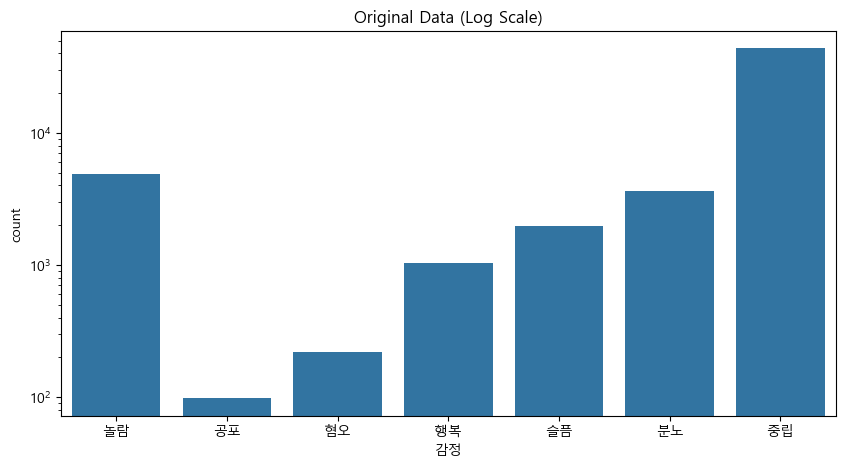

In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from konlpy.tag import Okt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter
import matplotlib.pyplot

# 한글 폰트 설정 (맥OS 기준)
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

torch.manual_seed(42)
np.random.seed(42)

# 0. 데이터 로드 및 로그 스케일 시각화(EDA)
df = pd.read_csv('cleaned_korean.csv')

def plot_log_dist(data, title):
    plt.figure(figsize=(10, 5))
    sns.countplot(x='감정', data=data, order=['놀람', '공포', '혐오', '행복', '슬픔', '분노', '중립'])
    plt.yscale('log')
    plt.title(title)
    plt.savefig('log.png')
    plt.show()

plot_log_dist(df, "Original Data (Log Scale)")

In [204]:
# ---------------------------------------------------------
# 1. 전체 데이터에 대해 Okt 토큰화 (전체를 다 돌린 후)
# ---------------------------------------------------------
okt = Okt()
def tokenize(text):
    return [word for word in okt.morphs(str(text), stem=True) if len(word) > 1]

# print("주의: 5만 건 전체 토큰화는 시간이 꽤 걸립니다...")
df['tokenized'] = df['발화'].apply(tokenize)

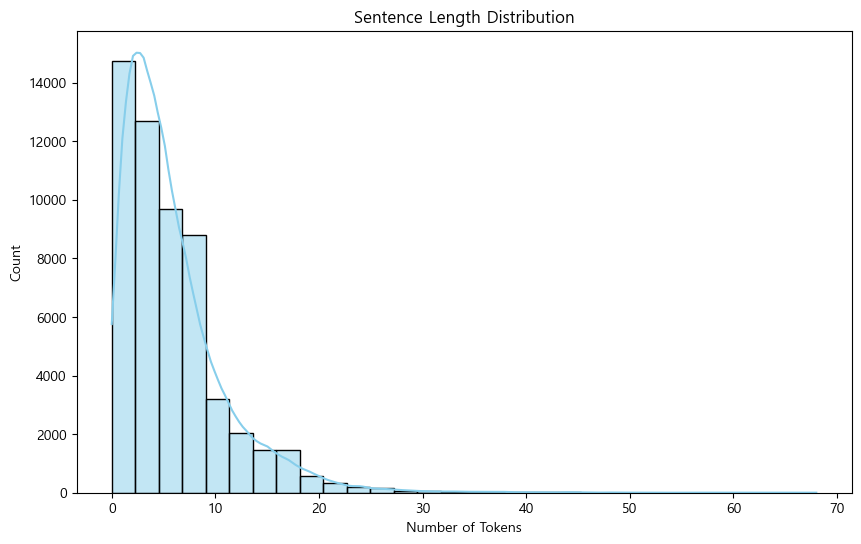

평균 문장 길이: 5.87
최대 문장 길이: 68


In [205]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 문장별 토큰 개수 계산 (df['tokenized']는 이미 토큰화된 리스트라고 가정)
df['sentence_len'] = df['tokenized'].apply(len)

# 2. 히스토그램 그리기
plt.figure(figsize=(10, 6))
sns.histplot(df['sentence_len'], bins=30, kde=True, color='skyblue')
plt.title('Sentence Length Distribution')
plt.xlabel('Number of Tokens')
plt.ylabel('Count')
plt.savefig('sentence.png')
plt.show()

# 3. 평균 및 최대 길이 확인 (발표 스크립트에 활용)
print(f"평균 문장 길이: {df['sentence_len'].mean():.2f}")
print(f"최대 문장 길이: {df['sentence_len'].max()}")

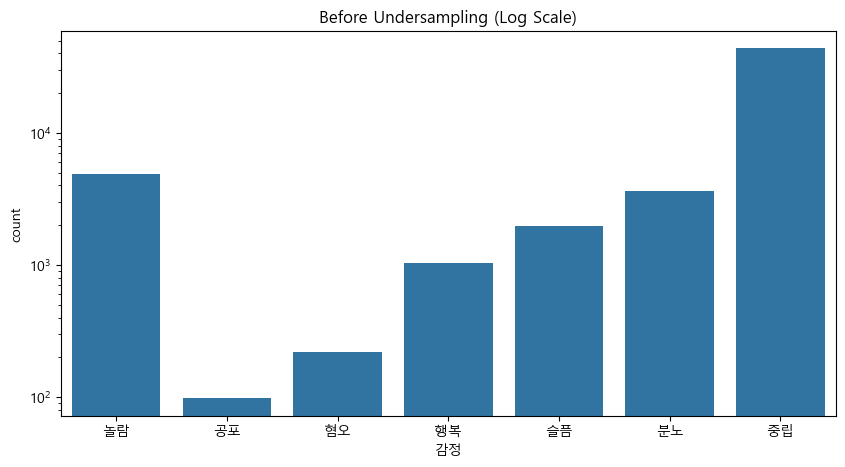

In [206]:
# ---------------------------------------------------------
# 2. 로그 스케일 분포 확인
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.countplot(x='감정', data=df, order=['놀람', '공포', '혐오', '행복', '슬픔', '분노', '중립'])
plt.yscale('log') # 로그 스케일 적용
plt.title("Before Undersampling (Log Scale)")
plt.savefig('log2.png')
plt.show()

In [207]:
# 3. 10배 언더샘플링 
# ---------------------------------------------------------
# 방법 1: 소수 클래스(공포 98개)의 10배인 약 1,000개로 맞추기 (권장)
min_size = df['감정'].value_counts().min()
target_n = min_size * 10

def do_undersample(data, n):
    # 1. '감정'별로 데이터를 그룹화합니다.
    groups = data.groupby('감정')
    
    sampled_list = []
    for name, group in groups:
        # 2. 각 그룹에서 n개(또는 데이터 전체)를 샘플링합니다.
        sampled_group = group.sample(n=min(len(group), n), random_state=42)
        sampled_list.append(sampled_group)
    
    # 3. 샘플링된 그룹들을 다시 하나로 합치고 인덱스를 초기화합니다.
    return pd.concat(sampled_list).reset_index(drop=True)

# 10배수 타겟 설정 (공포 98개 기준 980개)
min_size = df['감정'].value_counts().min()
target_n = min_size * 10 

# 함수 실행
df_balanced = do_undersample(df, target_n)

# 확인
print(f"샘플링 후 컬럼 목록: {df_balanced.columns.tolist()}")
print(f"샘플링 후 분포:\n{df_balanced['감정'].value_counts()}")

샘플링 후 컬럼 목록: ['발화', '감정', 'label', 'tokenized', 'sentence_len']
샘플링 후 분포:
감정
놀람    980
분노    980
슬픔    980
중립    980
행복    980
혐오    220
공포     98
Name: count, dtype: int64


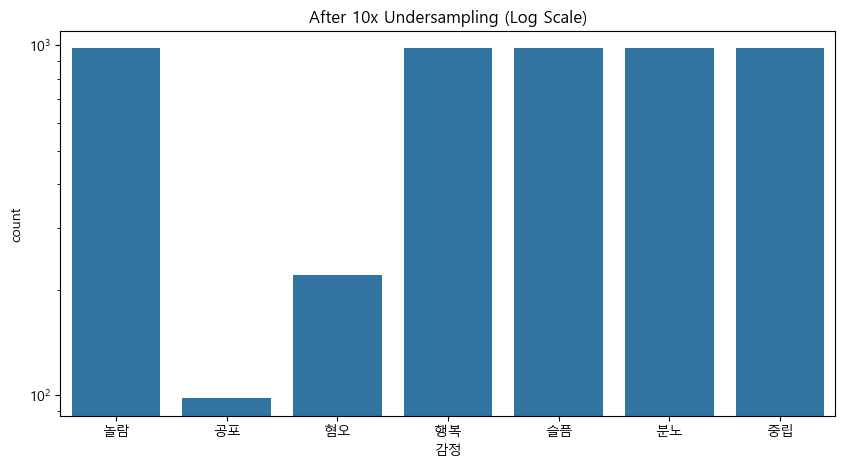

샘플링 후 감정별 데이터 개수:
감정
공포     98
놀람    980
분노    980
슬픔    980
중립    980
행복    980
혐오    220
Name: count, dtype: int64


In [208]:
# ---------------------------------------------------------
# 언더샘플링 후 로그 스케일 분포 확인
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
# df_balanced는 이전 단계에서 생성된 언더샘플링된 데이터프레임입니다.
sns.countplot(x='감정', data=df_balanced, order=['놀람', '공포', '혐오', '행복', '슬픔', '분노', '중립'])
plt.yscale('log') # y축에 로그 스케일을 적용하여 소수 감정(공포)이 잘 보이는지 확인
plt.title("After 10x Undersampling (Log Scale)")
plt.savefig('log3')
plt.show()

# 실제 수치로도 확인해 봅니다.
print("샘플링 후 감정별 데이터 개수:")
print(df_balanced['감정'].value_counts().sort_index())

2단계: 단어 사전 생성 완료 (사전 크기: 2292)
전체 고유 단어 수: 4675개
단 1번만 등장한 단어(노이즈) 수: 2385개 (비율: 51.02%)
2번 이상 등장하여 사전에 등록된 단어 수: 2290개


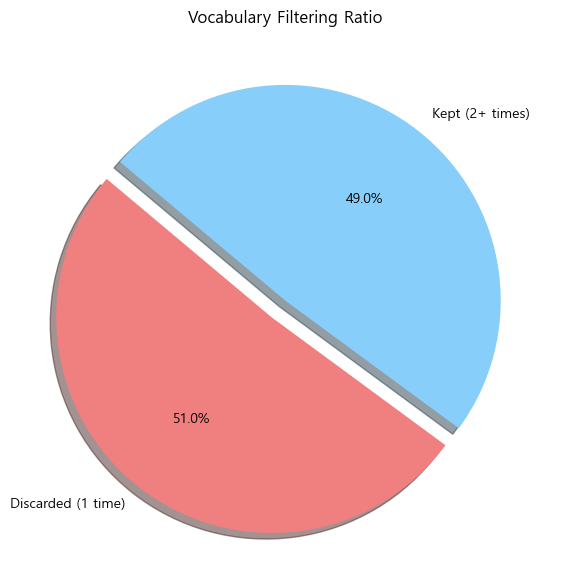

In [209]:
# ---------------------------------------------------------
# [2단계] 단어 사전 만들기 (Vocabulary) - 논리 오류 수정 완료
# ---------------------------------------------------------
from collections import Counter

# 모든 토큰을 모아 빈도수 계산
all_words = [word for tokens in df_balanced['tokenized'] for word in tokens]
word_counts = Counter(all_words)

# 1. 빈도수가 2 이상인 유의미한 단어만 먼저 추출
valid_words = [word for word, count in word_counts.items() if count >= 2]

# 2. 추출된 단어들에게만 2번부터 연속적인 인덱스 부여 (이빨 빠짐 방지)
vocab = {word: i+2 for i, word in enumerate(valid_words)}

# 3. 특수 토큰 추가
vocab['<PAD>'] = 0  # 패딩용 번호
vocab['<UNK>'] = 1  # 모르는 단어용 번호

vocab_size = len(vocab)
print(f"2단계: 단어 사전 생성 완료 (사전 크기: {vocab_size})")

# --- 단어 빈도수 통계 출력 ---
total_words_count = len(word_counts)
vocab_size_filtered = len(vocab) - 2  # <PAD>, <UNK> 2개 제외한 실제 단어 수
single_use_words = total_words_count - vocab_size_filtered

print(f"전체 고유 단어 수: {total_words_count}개")
print(f"단 1번만 등장한 단어(노이즈) 수: {single_use_words}개 (비율: {single_use_words/total_words_count*100:.2f}%)")
print(f"2번 이상 등장하여 사전에 등록된 단어 수: {vocab_size_filtered}개")

# --- 시각화 (옵션) ---
import matplotlib.pyplot as plt
labels = ['Discarded (1 time)', 'Kept (2+ times)']
sizes = [single_use_words, vocab_size_filtered]
colors = ['lightcoral', 'lightskyblue']
explode = (0.1, 0)  

plt.figure(figsize=(7, 7))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Vocabulary Filtering Ratio')
plt.savefig('vocab_pie.png')
plt.show()

In [210]:
# ---------------------------------------------------------
# [3단계] 정수 인코딩 및 패딩 (Encoding & Padding)
# ---------------------------------------------------------
max_len = 30 # 문장 최대 길이 고정

def encode_and_pad(tokens, vocab, max_len):
    # 정수 인코딩: 사전에 없으면 <UNK> 번호인 1 부여
    encoded = [vocab.get(token, 1) for token in tokens]
    # 패딩: 길면 자르고 짧으면 0(<PAD>)으로 채움
    if len(encoded) < max_len:
        encoded += [0] * (max_len - len(encoded))
    else:
        encoded = encoded[:max_len]
    return encoded

print("3단계: 인코딩 및 패딩 진행 중...")
X = np.array([encode_and_pad(t, vocab, max_len) for t in df_balanced['tokenized']])
y = df_balanced['label'].values

3단계: 인코딩 및 패딩 진행 중...


In [211]:
# import torch.nn as nn

# class EmotionRNN(nn.Module):
#     def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
#         super(EmotionRNN, self).__init__()
#         # 1. 임베딩: 단어를 숫자로 변환
#         self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
#         # 2. 기본 RNN 층 (LSTM 대신 nn.RNN 사용)
#         # RNN은 LSTM과 달리 '셀 상태(cell state)'가 없어 장기 기억력이 약합니다.
#         self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        
#         # 3. 출력 층
#         self.fc = nn.Linear(hidden_dim, output_dim)
        
#     def forward(self, x):
#         # x: (batch_size, max_len)
#         embedded = self.embedding(x) # (batch_size, max_len, embed_dim)
        
#         # RNN의 출력: output은 모든 시점의 은닉 상태, hidden은 마지막 시점의 은닉 상태
#         _, hidden = self.rnn(embedded)
        
#         # 마지막 시점의 정보(hidden[-1])만 사용하여 분류
#         out = self.fc(hidden[-1])
#         return out

# # 모델 생성 (파라미터는 동료의 LSTM과 똑같이 맞춰야 공정한 비교가 됩니다)
# model = EmotionRNN(vocab_size=len(vocab), embed_dim=100, hidden_dim=128, output_dim=7).to(device)

In [212]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import os

# ---------------------------------------------------------
# [복구됨] 1. 데이터셋 정의 (길이 반환 포함)
# ---------------------------------------------------------
class EmotionDataset(Dataset):
    def __init__(self, dataframe, vocab, max_len=50):
        self.X = []
        self.lengths = [] # 실제 문장 길이를 저장할 리스트
        
        for tokens in dataframe['tokenized']:
            encoded = [vocab.get(token, vocab['<UNK>']) for token in tokens]
            
            # 실제 길이 계산 (최대 길이 max_len을 넘지 않도록)
            valid_len = min(len(encoded), max_len)
            # 빈 문장 방지
            if valid_len == 0:
                valid_len = 1
                encoded = [vocab['<UNK>']]
                
            self.lengths.append(valid_len)

            if len(encoded) < max_len:
                encoded += [vocab['<PAD>']] * (max_len - len(encoded))
            else:
                encoded = encoded[:max_len]
            self.X.append(encoded)
        
        self.X = torch.tensor(self.X, dtype=torch.long)
        self.y = torch.tensor(dataframe['label'].values.copy(), dtype=torch.long)
        self.lengths = torch.tensor(self.lengths, dtype=torch.long)

    def __len__(self): 
        return len(self.X)
        
    def __getitem__(self, i): 
        return self.X[i], self.y[i], self.lengths[i]

In [213]:
# ---------------------------------------------------------
# [복구됨] 2. 데이터 3분할(Train/Val/Test) 및 DataLoader 설정
# ---------------------------------------------------------
# 1차 분할: Train+Val(80%) / Test(20%) 분리
df_temp, df_test = train_test_split(df_balanced, test_size=0.2, random_state=42, stratify=df_balanced['label'])

# 2차 분할: Train(60%) / Validation(20%) 분리 (df_temp 내에서 75:25 비율)
df_train, df_val = train_test_split(df_temp, test_size=0.25, random_state=42, stratify=df_temp['label'])

# 데이터셋 객체 생성
train_dataset = EmotionDataset(df_train, vocab)
val_dataset = EmotionDataset(df_val, vocab)
test_dataset = EmotionDataset(df_test, vocab)

# DataLoader 설정
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [214]:
# ---------------------------------------------------------
# [복구 및 주석 해제됨] 3. RNN 모델 정의 (pack_padded_sequence 적용)
# ---------------------------------------------------------
class EmotionRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(EmotionRNN, self).__init__()
        # 패딩 인덱스는 0으로 지정하여 기울기 업데이트 방지
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x, lengths):
        embedded = self.embedding(x)
        
        # 패딩된 데이터를 압축하여 무의미한 연산 방지
        packed_input = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        
        # RNN 통과
        packed_output, hidden = self.rnn(packed_input)
        
        # 마지막 시점의 은닉 상태(hidden[-1])를 FC 레이어에 전달하여 최종 분류
        return self.fc(hidden[-1])

In [215]:
# ---------------------------------------------------------
# [복구됨] 4. 장치 설정, 모델 인스턴스화 및 하이퍼파라미터
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 중인 장치: {device}")

EMBED_DIM = 128
HIDDEN_DIM = 64
LR = 0.001
EPOCHS = 100

# 단어 사전 크기는 패딩(0)과 UNK(1)를 포함하여 안전하게 설정
safe_vocab_size = len(vocab) + 2 

model = EmotionRNN(safe_vocab_size, EMBED_DIM, HIDDEN_DIM, 7).to(device)
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=LR)

사용 중인 장치: cpu


In [216]:
# ---------------------------------------------------------
# 5. 학습 및 검증 루프 (최종 검증 정확도 기록 포함)
# ---------------------------------------------------------
train_hist = []
val_hist = []
best_loss = float('inf')
best_val_acc = 0.0  # 1. 최고 검증 정확도를 저장할 변수 초기화
patience = 2
counter = 0

for epoch in range(EPOCHS):
    # ==========================================
    # --- 1. Training (학습) ---
    # ==========================================
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for inputs, targets, lengths in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        
        outputs = model(inputs, lengths)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
        # 정확도 계산
        _, predicted = torch.max(outputs, 1)
        train_total += targets.size(0)
        train_correct += (predicted == targets).sum().item()
    
    avg_train_loss = train_loss / len(train_loader)
    train_acc = train_correct / train_total
    train_hist.append(avg_train_loss)

    # ==========================================
    # --- 2. Validation (검증) ---
    # ==========================================
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, targets, lengths in val_loader: 
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs, lengths)
            loss = criterion(outputs, targets)
            val_loss += loss.item()
            
            # 정확도 계산
            _, predicted = torch.max(outputs, 1)
            val_total += targets.size(0)
            val_correct += (predicted == targets).sum().item()
    
    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total
    val_hist.append(avg_val_loss)
    
    # 결과 출력
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Early Stopping 및 Best Model 저장 로직
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        best_val_acc = val_acc  # 2. 오차가 가장 낮을 때(Best Model)의 정확도를 갱신 및 기록
        torch.save(model.state_dict(), 'best_emotion_rnn.pt')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early Stopping 적용됨")
            break

# 3. 루프가 완전히 끝난 뒤 최종 성능 출력
print(f"\n최종 검증 정확도 (Best Val Acc): {best_val_acc:.4f}")

Epoch [1/100] - Train Loss: 1.8502, Train Acc: 0.2323 | Val Loss: 1.7658, Val Acc: 0.2883
Epoch [2/100] - Train Loss: 1.6779, Train Acc: 0.3236 | Val Loss: 1.7195, Val Acc: 0.2960
Epoch [3/100] - Train Loss: 1.6016, Train Acc: 0.3741 | Val Loss: 1.6981, Val Acc: 0.3238
Epoch [4/100] - Train Loss: 1.5220, Train Acc: 0.4201 | Val Loss: 1.6809, Val Acc: 0.3544
Epoch [5/100] - Train Loss: 1.4419, Train Acc: 0.4585 | Val Loss: 1.6884, Val Acc: 0.3400
Epoch [6/100] - Train Loss: 1.3531, Train Acc: 0.5032 | Val Loss: 1.6992, Val Acc: 0.3496
Early Stopping 적용됨

최종 검증 정확도 (Best Val Acc): 0.3544



'best_emotion_rnn.pt' 파일을 찾았습니다. 시각화를 시작합니다.


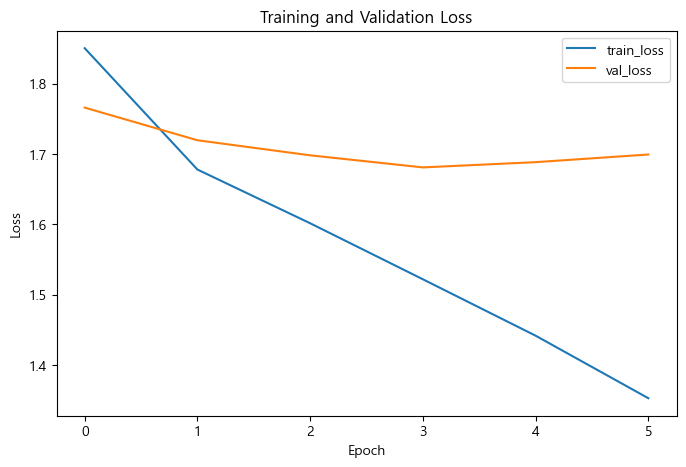

최종 테스트 데이터 정확도 (Final Test Accuracy): 0.3209

[상세 성능 지표]
              precision    recall  f1-score   support

          놀람       0.41      0.42      0.42       196
          공포       0.00      0.00      0.00        20
          혐오       0.00      0.00      0.00        44
          행복       0.36      0.39      0.38       196
          슬픔       0.35      0.40      0.37       196
          분노       0.29      0.36      0.32       196
          중립       0.17      0.14      0.15       196

    accuracy                           0.32      1044
   macro avg       0.23      0.24      0.23      1044
weighted avg       0.30      0.32      0.31      1044



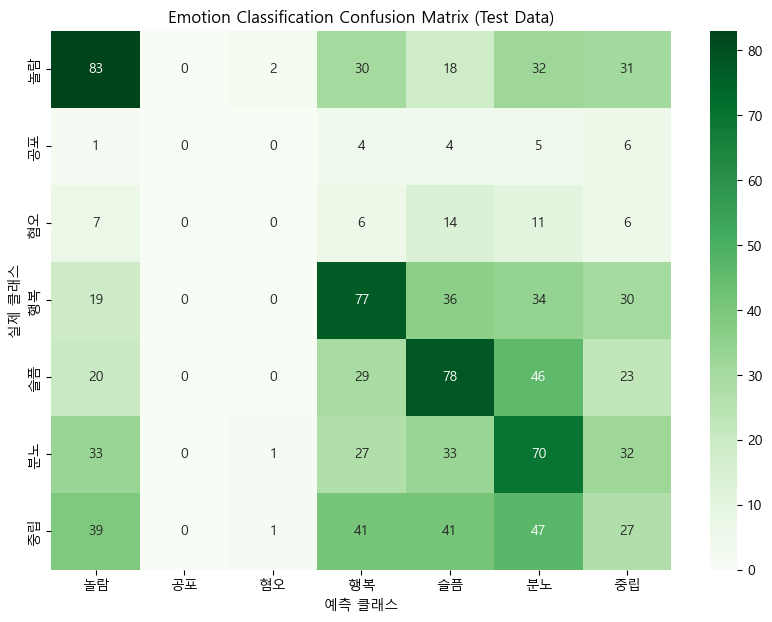

In [217]:
# ---------------------------------------------------------
# 6. 시각화 및 결과 분석 (최종 테스트 정확도 출력 추가)
# ---------------------------------------------------------
from sklearn.metrics import accuracy_score # 정확도 계산을 위해 추가

model_path = 'best_emotion_rnn.pt'

if os.path.exists(model_path):
    print(f"\n'{model_path}' 파일을 찾았습니다. 시각화를 시작합니다.")
    model.load_state_dict(torch.load(model_path))
    
    # 1. Loss 그래프 시각화
    plt.figure(figsize=(8, 5))
    plt.plot(train_hist, label='train_loss')
    plt.plot(val_hist, label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.savefig('loss_graph.png')
    plt.show()

    # 2. 테스트 데이터 예측
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for inputs, targets, lengths in test_loader:
            outputs = model(inputs.to(device), lengths)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_targets.extend(targets.numpy())

    # --- 핵심: 최종 테스트 정확도 계산 및 출력 ---
    test_accuracy = accuracy_score(all_targets, all_preds)
    print("="*50)
    print(f"최종 테스트 데이터 정확도 (Final Test Accuracy): {test_accuracy:.4f}")
    print("="*50)

    # 3. 상세 성능 지표(Classification Report) 출력
    try:
        target_names = list(data_mapping.keys())
        print("\n[상세 성능 지표]")
        print(classification_report(all_targets, all_preds, target_names=target_names, zero_division=0))

        # 4. 혼동 행렬(Confusion Matrix) 시각화
        cm = confusion_matrix(all_targets, all_preds)
        plt.figure(figsize=(10, 7))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                    xticklabels=target_names, yticklabels=target_names)
        plt.title('Emotion Classification Confusion Matrix (Test Data)')
        plt.xlabel('예측 클래스')
        plt.ylabel('실제 클래스')
        plt.savefig('test_confusion_matrix.png')
        plt.show()
    except NameError:
        print("경고: 'data_mapping' 변수가 정의되지 않아 시각화 일부를 건너뜜.")
else:
    print(f"!!! 에러: '{model_path}' 파일이 존재하지 않음.")


=== 상세 성능 지표 (Classification Report) ===
              precision    recall  f1-score   support

          놀람       0.41      0.42      0.42       196
          공포       0.00      0.00      0.00        20
          혐오       0.00      0.00      0.00        44
          행복       0.36      0.39      0.38       196
          슬픔       0.35      0.40      0.37       196
          중립       0.29      0.36      0.32       196
          혐오       0.17      0.14      0.15       196

    accuracy                           0.32      1044
   macro avg       0.23      0.24      0.23      1044
weighted avg       0.30      0.32      0.31      1044



c:\Users\KDS30\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\KDS30\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\KDS30\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

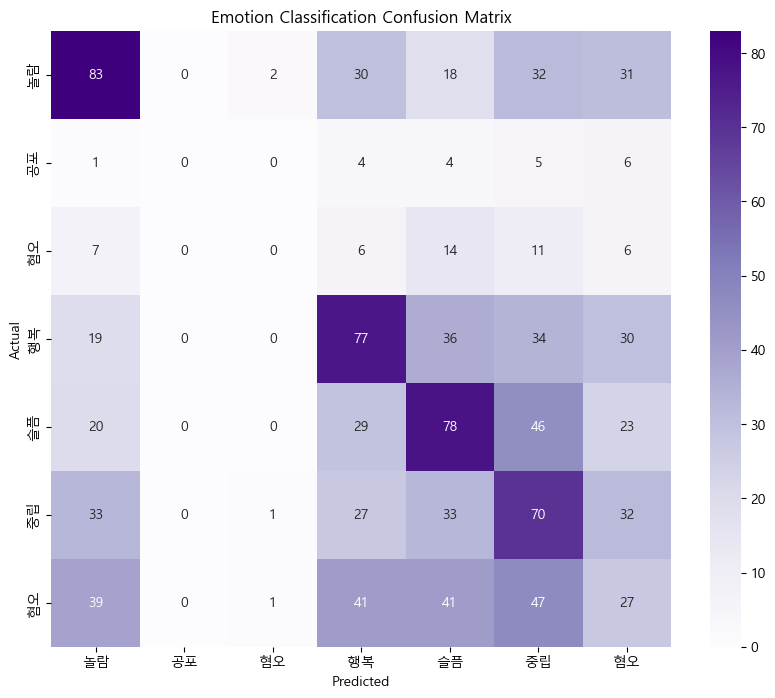

In [218]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 최적 모델 불러오기
model.load_state_dict(torch.load('best_emotion_rnn.pt'))
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets, lengths in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs, lengths)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# target_names는 데이터 정제 시 사용한 라벨 순서대로 입력하세요
target_names = ['놀람', '공포', '혐오', '행복', '슬픔', '중립', '혐오']

print("\n=== 상세 성능 지표 (Classification Report) ===")
print(classification_report(all_targets, all_preds, target_names=target_names))

# 시각화 (Confusion Matrix)

plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_targets, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Emotion Classification Confusion Matrix')
plt.savefig('confusion.png')
plt.show()

c:\Users\KDS30\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\KDS30\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\KDS30\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

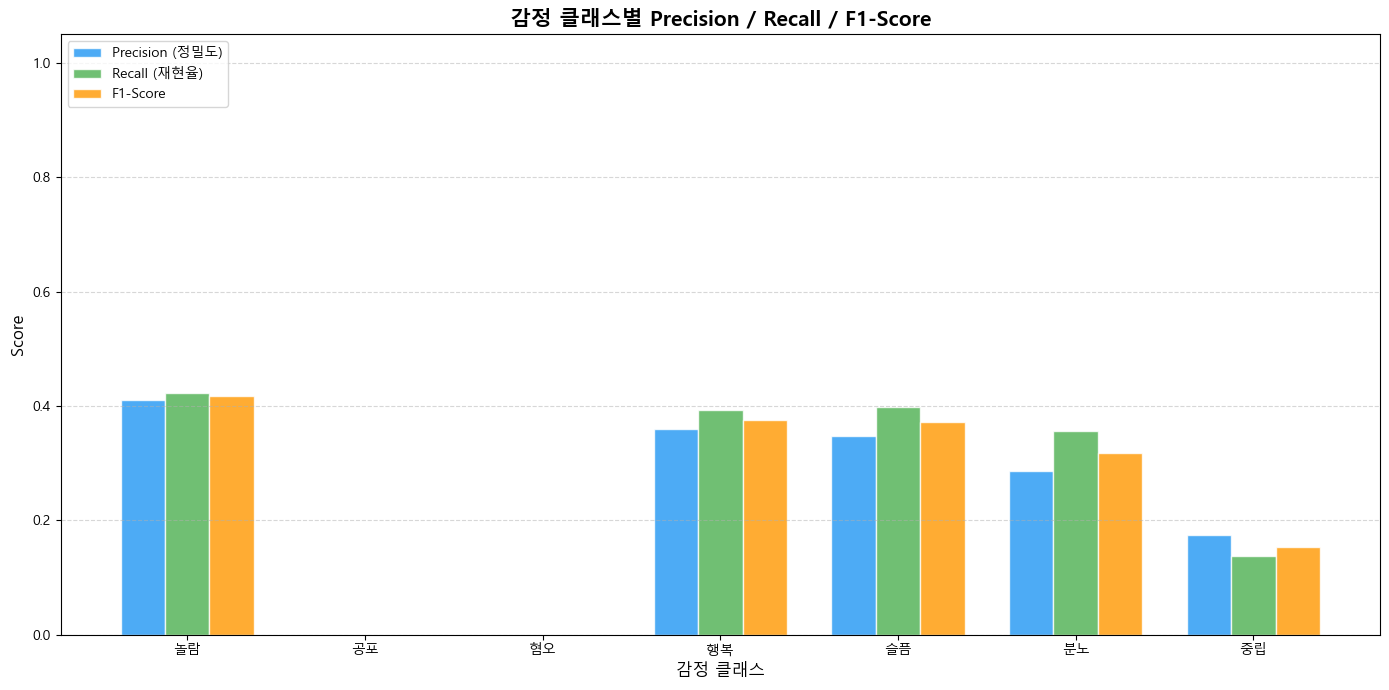

전체 Macro Avg F1-Score: 0.2336


In [219]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

# 최적 모델 로드 후 예측값 산출
model.load_state_dict(torch.load('best_emotion_rnn.pt'))
model.eval()

all_labels = []
all_preds = []
with torch.no_grad():
    for inputs, targets, lengths in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs, lengths)
        _, predicted = torch.max(outputs, 1)
        all_labels.extend(targets.numpy())
        all_preds.extend(predicted.cpu().numpy())

# 클래스명 설정
CLASS_NAMES_KO = ['놀람', '공포', '혐오', '행복', '슬픔', '분노', '중립']

# 리포트 생성
report = classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES_KO,
    output_dict=True
)

# ================================================================
# 클래스별 상세 성능 지표 시각화 (Bar Chart)
# ================================================================
metrics = ['precision', 'recall', 'f1-score']
x = np.arange(len(CLASS_NAMES_KO))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))

colors = ['#2196F3', '#4CAF50', '#FF9800']
metric_labels = ['Precision (정밀도)', 'Recall (재현율)', 'F1-Score']

for i, (metric, color, label) in enumerate(zip(metrics, colors, metric_labels)):
    values = [report[cls][metric] for cls in CLASS_NAMES_KO]
    ax.bar(x + i*width, values, width, label=label, color=color, alpha=0.8, edgecolor='white')

ax.set_xlabel('감정 클래스', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('감정 클래스별 Precision / Recall / F1-Score', fontsize=15, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_NAMES_KO)
ax.legend(loc='upper left')
ax.set_ylim([0, 1.05]) # 성능에 따라 하한값을 조정하세요 (예: 0.5 ~ 1.0)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('class.png')
plt.show()

print(f"전체 Macro Avg F1-Score: {report['macro avg']['f1-score']:.4f}")

In [220]:
def predict_emotion(sentence, model, tokenizer, vocab, max_len, device):
    model.eval()
    
    # 1. 토큰화 (전처리 단계에서 쓴 Okt 등 동일하게 사용)
    tokens = okt.morphs(sentence) 
    
    # 2. 정수 인코딩 및 패딩
    encoded = [vocab.get(token, vocab['<UNK>']) for token in tokens]
    length = len(encoded)
    if length < max_len:
        encoded += [vocab['<PAD>']] * (max_len - length)
    else:
        encoded = encoded[:max_len]
        length = max_len
        
    pad_tensor = torch.LongTensor([encoded]).to(device)
    len_tensor = torch.LongTensor([length]) # 길이는 CPU에 있어도 모델 내부 처리에 따라 다를 수 있음
    
    # 3. 예측
    with torch.no_grad():
        output = model(pad_tensor, len_tensor)
        _, predicted = torch.max(output, 1)
        
    return target_names[predicted.item()]

# 테스트 실행
test_sentences = ["아 오늘 진짜 짜증나네", "어머, 정말 대단하다!", "와 진짜 무섭다 이거", "그냥 평범한 하루야"]

print("\n=== 실제 문장 테스트 결과 ===")
for sent in test_sentences:
    res = predict_emotion(sent, model, okt, vocab, max_len, device)
    print(f"입력: {sent} -> 예측: {res}")


=== 실제 문장 테스트 결과 ===
입력: 아 오늘 진짜 짜증나네 -> 예측: 놀람
입력: 어머, 정말 대단하다! -> 예측: 혐오
입력: 와 진짜 무섭다 이거 -> 예측: 놀람
입력: 그냥 평범한 하루야 -> 예측: 혐오


In [221]:
# import torch
# import torch.nn as nn
# import torch.optim as optim

# # [모델 정의]: 다층(Multi-layer) 구조 및 드롭아웃 적용
# class EmotionRNN_Tuned(nn.Module):
#     def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, num_layers=2, dropout=0.5):
#         super(EmotionRNN_Tuned, self).__init__()
#         self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
#         # num_layers를 2 이상으로 주어 모델의 표현력을 높이고, dropout 적용
#         self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers=num_layers, 
#                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
#         self.dropout = nn.Dropout(dropout)
#         self.fc = nn.Linear(hidden_dim, output_dim)
        
#     def forward(self, x, lengths):
#         embedded = self.embedding(x)
#         packed_input = nn.utils.rnn.pack_padded_sequence(
#             embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
#         )
#         packed_output, hidden = self.rnn(packed_input)
        
#         # hidden shape: (num_layers, batch, hidden_dim)
#         # 최상단 레이어의 마지막 은닉 상태를 추출 후 드롭아웃 통과
#         out = self.dropout(hidden[-1])
#         return self.fc(out)

# # [옵티마이저 튜닝]: L2 정규화(weight_decay) 추가
# model_rnn = EmotionRNN_Tuned(safe_vocab_size, EMBED_DIM=128, HIDDEN_DIM=64, output_dim=7, num_layers=2, dropout=0.5).to(device)

# # 가중치 불균형이 심하다면 클래스별 가중치를 역산하여 criterion에 부여하는 것도 필수적입니다.
# criterion = nn.CrossEntropyLoss() 
# optimizer = optim.Adam(model_rnn.parameters(), lr=0.001, weight_decay=1e-4)

# # [학습 루프 내부 튜닝]: 기울기 클리핑 추가
# # ... (기존 학습 루프와 동일) ...
#         # loss = criterion(outputs, targets)
#         # loss.backward()
        
#         # 역전파 직후, optimizer.step() 이전에 아래 코드 추가 (그래디언트 폭발 방지)
#         torch.nn.utils.clip_grad_norm_(model_rnn.parameters(), max_norm=1.0)
        
#         # optimizer.step()
# # ...

=== 성능 평가 지표 요약 ===
              precision    recall  f1-score   support

          놀람       0.41      0.42      0.42       196
          공포       0.00      0.00      0.00        20
          혐오       0.00      0.00      0.00        44
          행복       0.36      0.39      0.38       196
          슬픔       0.35      0.40      0.37       196
          분노       0.29      0.36      0.32       196
          중립       0.17      0.14      0.15       196

    accuracy                           0.32      1044
   macro avg       0.23      0.24      0.23      1044
weighted avg       0.30      0.32      0.31      1044


=== 혼동 행렬 시각화 ===


c:\Users\KDS30\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\KDS30\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\KDS30\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

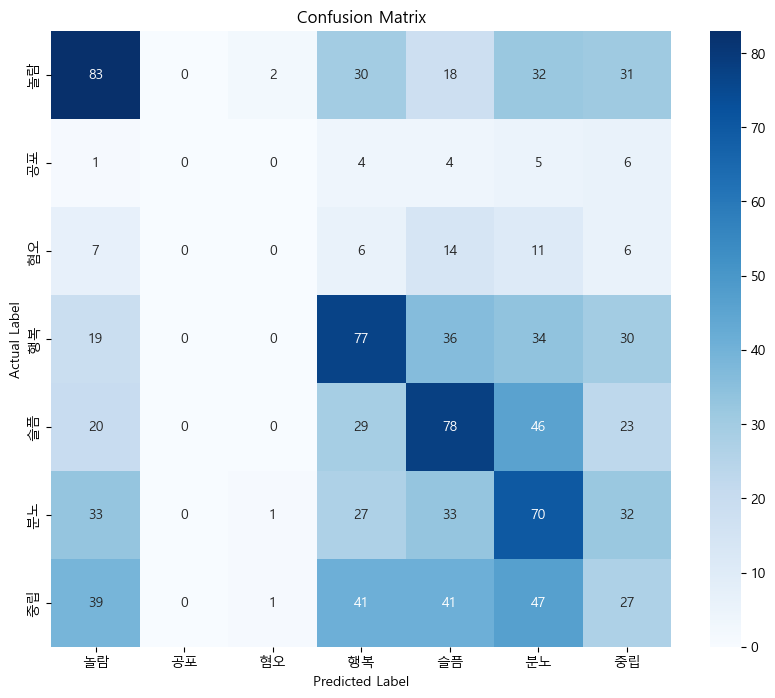

In [222]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

import torch
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 실제 정답과 예측값을 수집하는 평가 함수 정의
def get_predictions(model, test_loader, device):
    # 모델을 평가 모드로 전환 (Dropout 등 정규화 기법 비활성화)
    model.eval()
    
    y_true = []
    y_pred = []
    
    # 평가 시에는 기울기(Gradient)를 계산할 필요가 없으므로 비활성화
    with torch.no_grad():
        # [비판적 수정 1] test_loader가 3개의 값(inputs, labels, lengths)을 반환하므로 이를 모두 받아줍니다.
        for inputs, labels, lengths in test_loader:
            # 입력 데이터와 라벨을 연산 장치로 이동
            inputs, labels = inputs.to(device), labels.to(device)
            
            # [비판적 수정 2] 모델 순전파 시, 데이터의 실제 길이(lengths)도 모델에 함께 전달해야 작동합니다.
            outputs = model(inputs, lengths)
            
            # 출력값(Logits) 중 가장 큰 값의 인덱스(클래스)를 추출 
            _, predicted = torch.max(outputs, 1)
            
            # 텐서를 CPU 메모리로 내리고 배열로 변환하여 리스트에 추가
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            
    return y_true, y_pred

# ==========================================
# 2. 실제 실행 및 지표 출력 로직 
# ==========================================

# 모델(model) 변수가 학습이 완료된 그 객체를 제대로 가리키고 있는지 최종 확인하십시오.
y_true, y_pred = get_predictions(model, test_loader, device)

# 데이터 정제 단계에서 맵핑했던 라벨 순서와 동일하게 지정
target_names = ['놀람', '공포', '혐오', '행복', '슬픔', '분노', '중립']

# Macro F1-Score 및 클래스별 정밀도/재현율 출력
print("=== 성능 평가 지표 요약 ===")
print(classification_report(y_true, y_pred, target_names=target_names))

# 혼동 행렬 시각화
print("\n=== 혼동 행렬 시각화 ===")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

c:\Users\KDS30\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\KDS30\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\KDS30\anaconda3\envs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

최종 Macro F1-Score: 0.2336


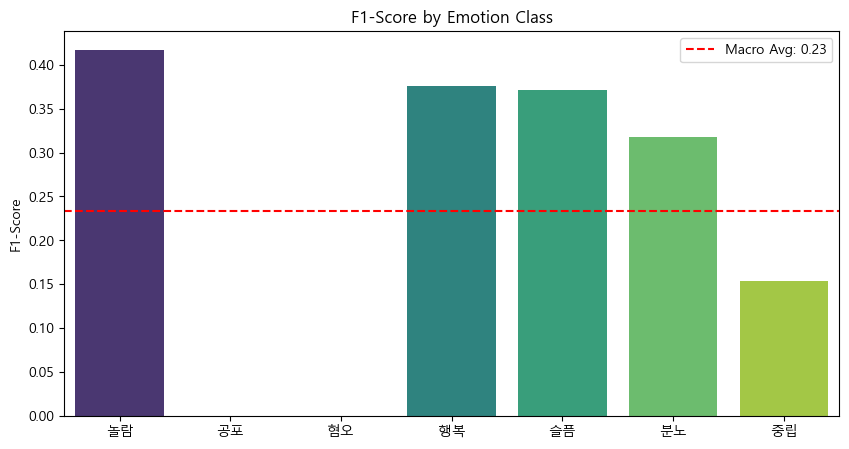

In [223]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# 1. 성능 리포트 생성 (이미 코드에 포함된 내용)
# target_names = ['공포', '놀람', '분노', '슬픔', '중립', '행복', '혐오']
report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)

# 2. Macro F1-score 추출 및 출력
macro_f1 = report['macro avg']['f1-score']
print(f"최종 Macro F1-Score: {macro_f1:.4f}")

# 3. 클래스별 F1-score 시각화 (슬라이드 삽입용)
f1_scores = [report[emotion]['f1-score'] for emotion in target_names]
plt.figure(figsize=(10, 5))
sns.barplot(x=target_names, y=f1_scores, palette='viridis')
plt.axhline(macro_f1, color='red', linestyle='--', label=f'Macro Avg: {macro_f1:.2f}')
plt.title('F1-Score by Emotion Class')
plt.ylabel('F1-Score')
plt.legend()
plt.show('macro.png')
plt.show()